## 概率论中常见的分布函数

概率分布通常分成两类：

- **离散型分布**：随机变量只能取有限个或可数个值，用概率质量函数 PMF：$P(X=k)$ 描述。
- **连续型分布**：随机变量可以在区间上连续取值，用概率密度函数 PDF：$f(x)$ 描述；真正的概率来自区间积分，例如 $P(a \le X \le b)=\int_a^b f(x)\,dx$。

下面整理常见分布的数学公式。这里把最常用的 PMF/PDF 作为主公式；如果需要完整的“分布函数”，也就是 CDF，则记作：

$$F(x)=P(X\le x)$$

---

## 离散型分布

| 分布 | 记号 | 概率质量函数 PMF | 典型含义 |
|---|---|---|---|
| 伯努利分布 | $X\sim\operatorname{Bernoulli}(p)$ | $P(X=k)=p^k(1-p)^{1-k},\quad k\in\{0,1\}$ | 一次 0/1 试验是否成功 |
| 二项分布 | $X\sim\operatorname{Binomial}(n,p)$ | $P(X=k)=\binom{n}{k}p^k(1-p)^{n-k},\quad k=0,1,\dots,n$ | $n$ 次独立伯努利试验中的成功次数 |
| 几何分布 | $X\sim\operatorname{Geometric}(p)$ | $P(X=k)=(1-p)^{k-1}p,\quad k=1,2,\dots$ | 第一次成功出现在第几次试验 |
| 泊松分布 | $X\sim\operatorname{Poisson}(\lambda)$ | $P(X=k)=\dfrac{\lambda^k e^{-\lambda}}{k!},\quad k=0,1,2,\dots$ | 单位时间 / 空间内事件发生次数 |

---

## 连续型分布

| 分布 | 记号 | 概率密度函数 PDF | 典型含义 |
|---|---|---|---|
| 均匀分布 | $X\sim\mathcal{U}(a,b)$ | $f(x)=\begin{cases}\dfrac{1}{b-a},&a\le x\le b\\0,&\text{otherwise}\end{cases}$ | 区间内各位置等可能 |
| 正态分布 / 高斯分布 | $X\sim\mathcal{N}(\mu,\sigma^2)$ | $f(x)=\dfrac{1}{\sigma\sqrt{2\pi}}\exp\!\left(-\dfrac{(x-\mu)^2}{2\sigma^2}\right)$ | 误差、身高、初始化噪声等钟形分布 |
| 拉普拉斯分布 | $X\sim\operatorname{Laplace}(\mu,b)$ | $f(x)=\dfrac{1}{2b}\exp\!\left(-\dfrac{|x-\mu|}{b}\right)$ | L1 正则化先验、鲁棒回归，尾部比正态分布更厚 |
| 指数分布 | $X\sim\operatorname{Exponential}(\lambda)$ | $f(x)=\lambda e^{-\lambda x},\quad x\ge0$ | 等待下一次事件发生的时间 |
| 伽马分布 | $X\sim\operatorname{Gamma}(\alpha,\theta)$ | $f(x)=\dfrac{x^{\alpha-1}e^{-x/\theta}}{\Gamma(\alpha)\theta^\alpha},\quad x>0$ | 等待第 $\alpha$ 次事件发生的时间，指数分布的推广 |
| Beta 分布 | $X\sim\operatorname{Beta}(\alpha,\beta)$ | $f(x)=\dfrac{x^{\alpha-1}(1-x)^{\beta-1}}{B(\alpha,\beta)},\quad 0<x<1$ | 建模概率、比例、点击率、Mixup 混合系数 |
| 卡方分布 | $X\sim\chi^2(k)$ | $f(x)=\dfrac{1}{2^{k/2}\Gamma(k/2)}x^{k/2-1}e^{-x/2},\quad x>0$ | 方差估计、拟合优度检验 |
| t 分布 | $X\sim t_\nu$ | $f(x)=\dfrac{\Gamma\left(\frac{\nu+1}{2}\right)}{\sqrt{\nu\pi}\Gamma\left(\frac{\nu}{2}\right)}\left(1+\dfrac{x^2}{\nu}\right)^{-\frac{\nu+1}{2}}$ | 小样本均值推断，比正态分布尾部更厚 |
| F 分布 | $X\sim F(d_1,d_2)$ | $f(x)=\dfrac{(d_1/d_2)^{d_1/2}x^{d_1/2-1}}{B(d_1/2,d_2/2)\left(1+d_1x/d_2\right)^{(d_1+d_2)/2}},\quad x>0$ | 比较两个方差，方差分析 ANOVA |

其中：

$$B(\alpha,\beta)=\frac{\Gamma(\alpha)\Gamma(\beta)}{\Gamma(\alpha+\beta)}$$

---

## Python 脚本：画常见分布示意图

下面的脚本只依赖 `numpy` 和 `matplotlib`，不依赖 `scipy`，方便直接在 notebook 里运行。

findfont: Failed to find font weight normal, now using 300.
findfont: Failed to find font weight normal, now using 300.


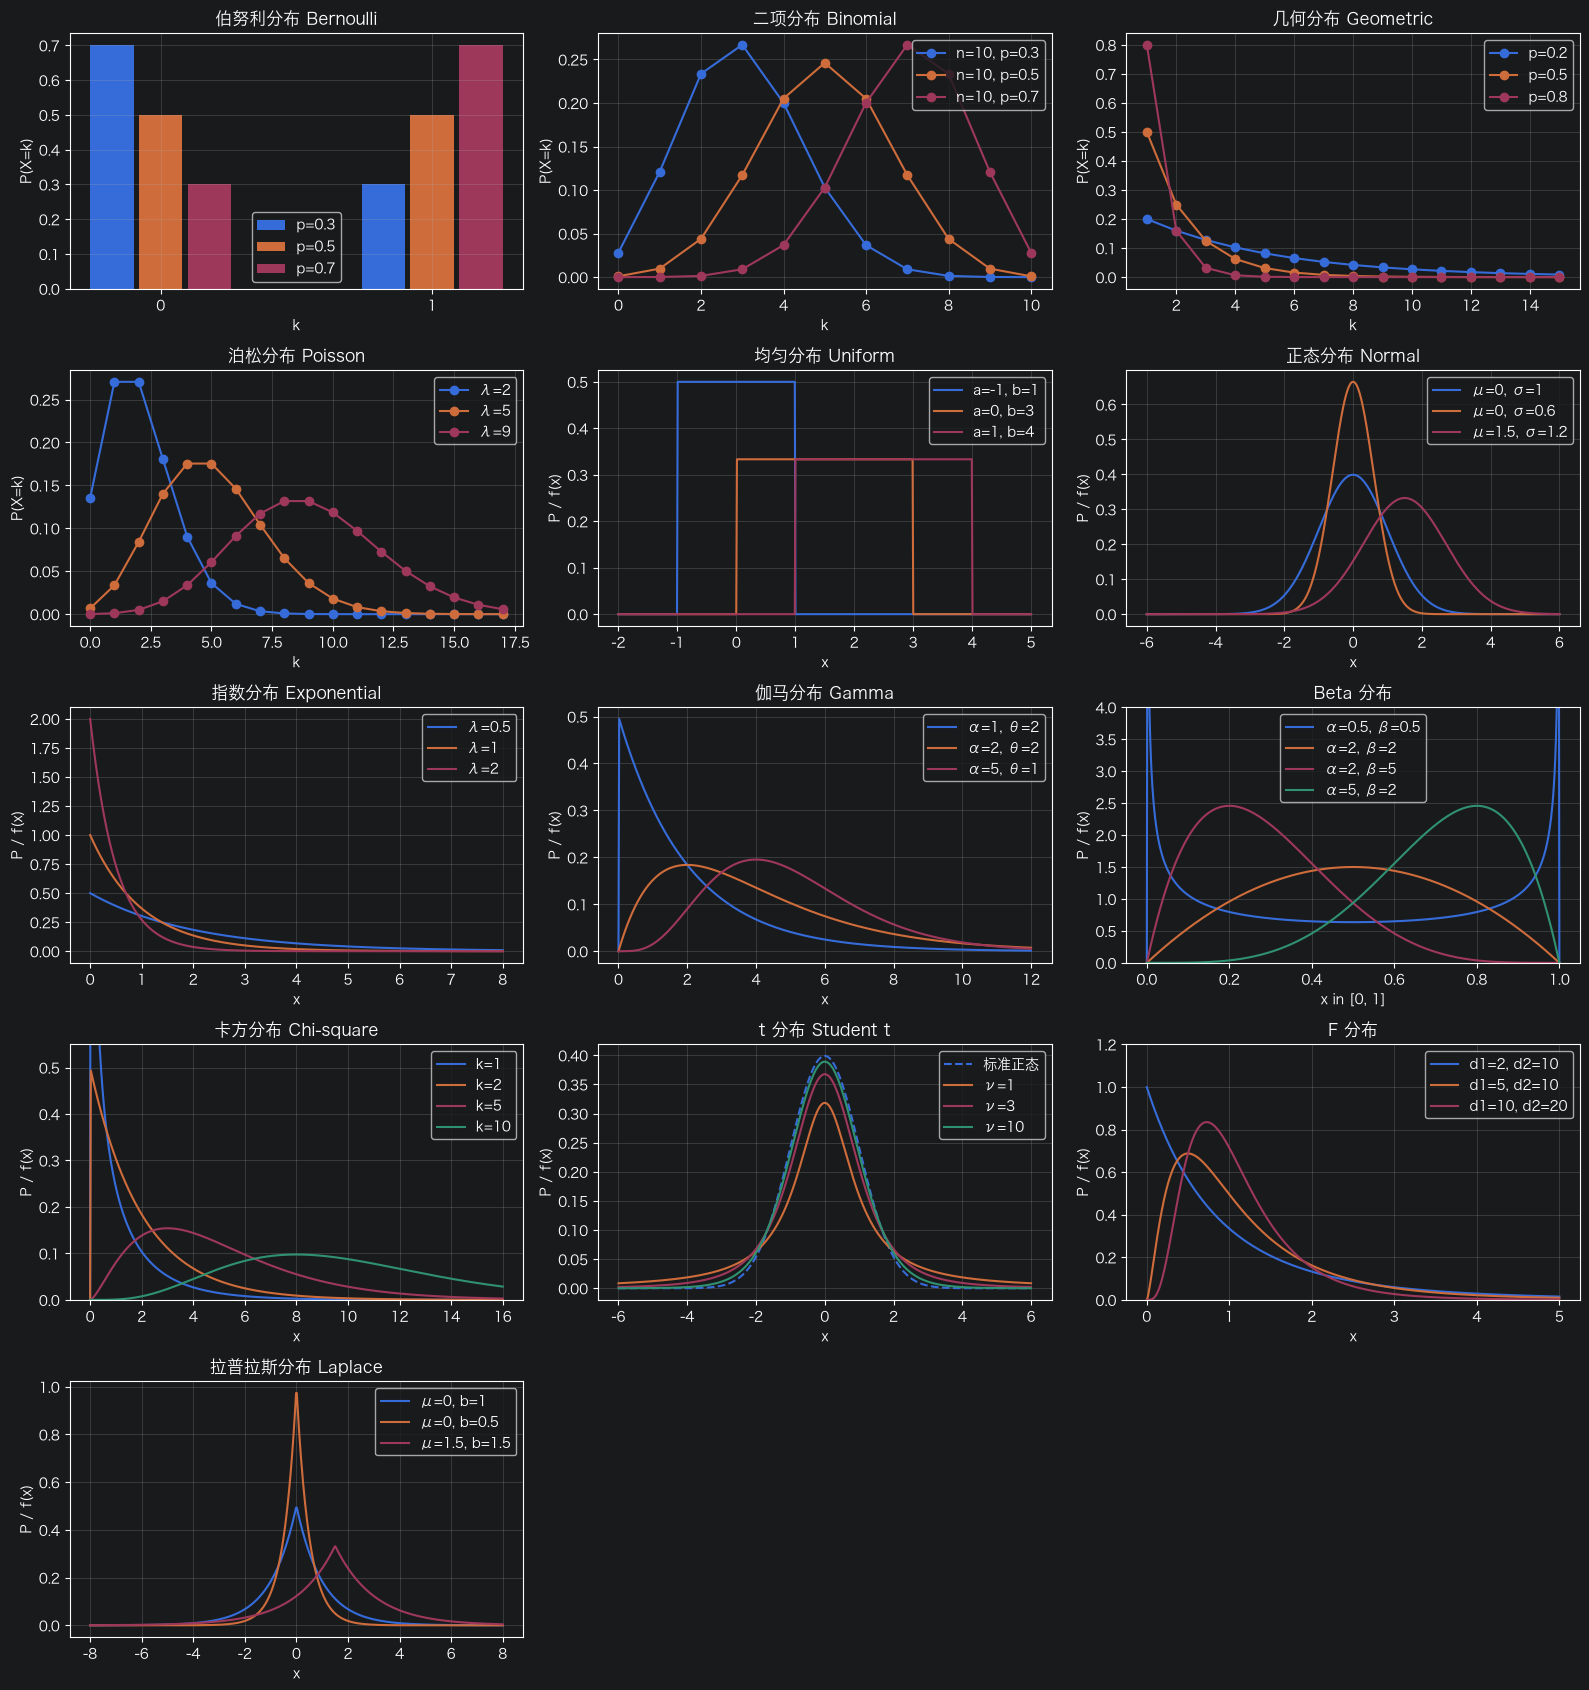

In [1]:
import math
import os

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# macOS 下优先使用中文字体；如果字体不存在，matplotlib 会自动回退。
font_path = '/System/Library/Fonts/Hiragino Sans GB.ttc'
if os.path.exists(font_path):
    fm.fontManager.addfont(font_path)
    plt.rcParams['font.family'] = 'Hiragino Sans GB'
plt.rcParams['axes.unicode_minus'] = False


def beta_func(a, b):
    return math.gamma(a) * math.gamma(b) / math.gamma(a + b)


def normal_pdf(x, mu=0, sigma=1):
    return np.exp(-0.5 * ((x - mu) / sigma) ** 2) / (sigma * np.sqrt(2 * np.pi))


def laplace_pdf(x, mu=0, b=1):
    return np.exp(-np.abs(x - mu) / b) / (2 * b)


def uniform_pdf(x, a=0, b=1):
    return np.where((x >= a) & (x <= b), 1 / (b - a), 0)


def exponential_pdf(x, lam=1):
    return np.where(x >= 0, lam * np.exp(-lam * x), 0)


def gamma_pdf(x, alpha=2, theta=1):
    y = np.zeros_like(x, dtype=float)
    mask = x > 0
    y[mask] = (x[mask] ** (alpha - 1) * np.exp(-x[mask] / theta)) / (math.gamma(alpha) * theta ** alpha)
    return y


def beta_pdf(x, alpha=2, beta=5):
    y = np.zeros_like(x, dtype=float)
    mask = (x > 0) & (x < 1)
    y[mask] = (x[mask] ** (alpha - 1) * (1 - x[mask]) ** (beta - 1)) / beta_func(alpha, beta)
    return y


def chi_square_pdf(x, k=4):
    y = np.zeros_like(x, dtype=float)
    mask = x > 0
    y[mask] = (x[mask] ** (k / 2 - 1) * np.exp(-x[mask] / 2)) / (2 ** (k / 2) * math.gamma(k / 2))
    return y


def t_pdf(x, nu=5):
    c = math.gamma((nu + 1) / 2) / (math.sqrt(nu * math.pi) * math.gamma(nu / 2))
    return c * (1 + x**2 / nu) ** (-(nu + 1) / 2)


def f_pdf(x, d1=5, d2=10):
    y = np.zeros_like(x, dtype=float)
    mask = x > 0
    c = (d1 / d2) ** (d1 / 2) / beta_func(d1 / 2, d2 / 2)
    y[mask] = c * x[mask] ** (d1 / 2 - 1) / (1 + d1 * x[mask] / d2) ** ((d1 + d2) / 2)
    return y


def style_axis(ax, title, xlabel='x', ylabel='P / f(x)'):
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3)


fig, axes = plt.subplots(5, 3, figsize=(16, 17))
axes = axes.ravel()

# 1. 伯努利分布
ax = axes[0]
ks = np.array([0, 1])
for offset, p in zip([-0.18, 0, 0.18], [0.3, 0.5, 0.7]):
    ax.bar(ks + offset, [1 - p, p], width=0.16, label=f'p={p}')
ax.set_xticks([0, 1])
ax.set_xticklabels(['0', '1'])
style_axis(ax, '伯努利分布 Bernoulli', xlabel='k', ylabel='P(X=k)')
ax.legend()

# 2. 二项分布
ax = axes[1]
n = 10
ks = np.arange(n + 1)
for p in [0.3, 0.5, 0.7]:
    probs = [math.comb(n, k) * p**k * (1 - p) ** (n - k) for k in ks]
    ax.plot(ks, probs, marker='o', label=f'n={n}, p={p}')
style_axis(ax, '二项分布 Binomial', xlabel='k', ylabel='P(X=k)')
ax.legend()

# 3. 几何分布
ax = axes[2]
ks = np.arange(1, 16)
for p in [0.2, 0.5, 0.8]:
    probs = (1 - p) ** (ks - 1) * p
    ax.plot(ks, probs, marker='o', label=f'p={p}')
style_axis(ax, '几何分布 Geometric', xlabel='k', ylabel='P(X=k)')
ax.legend()

# 4. 泊松分布
ax = axes[3]
ks = np.arange(0, 18)
for lam in [2, 5, 9]:
    probs = [lam**k * math.exp(-lam) / math.factorial(k) for k in ks]
    ax.plot(ks, probs, marker='o', label=f'λ={lam}')
style_axis(ax, '泊松分布 Poisson', xlabel='k', ylabel='P(X=k)')
ax.legend()

# 5. 均匀分布
ax = axes[4]
x = np.linspace(-2, 5, 600)
for a, b in [(-1, 1), (0, 3), (1, 4)]:
    ax.plot(x, uniform_pdf(x, a, b), label=f'a={a}, b={b}')
style_axis(ax, '均匀分布 Uniform')
ax.legend()

# 6. 正态分布
ax = axes[5]
x = np.linspace(-6, 6, 600)
for mu, sigma in [(0, 1), (0, 0.6), (1.5, 1.2)]:
    ax.plot(x, normal_pdf(x, mu, sigma), label=f'μ={mu}, σ={sigma}')
style_axis(ax, '正态分布 Normal')
ax.legend()

# 7. 指数分布
ax = axes[6]
x = np.linspace(0, 8, 600)
for lam in [0.5, 1, 2]:
    ax.plot(x, exponential_pdf(x, lam), label=f'λ={lam}')
style_axis(ax, '指数分布 Exponential')
ax.legend()

# 8. 伽马分布
ax = axes[7]
x = np.linspace(0, 12, 600)
for alpha, theta in [(1, 2), (2, 2), (5, 1)]:
    ax.plot(x, gamma_pdf(x, alpha, theta), label=f'α={alpha}, θ={theta}')
style_axis(ax, '伽马分布 Gamma')
ax.legend()

# 9. Beta 分布
ax = axes[8]
x = np.linspace(0, 1, 600)
for alpha, beta in [(0.5, 0.5), (2, 2), (2, 5), (5, 2)]:
    ax.plot(x, beta_pdf(x, alpha, beta), label=f'α={alpha}, β={beta}')
style_axis(ax, 'Beta 分布', xlabel='x in [0, 1]')
ax.set_ylim(0, 4)
ax.legend()

# 10. 卡方分布
ax = axes[9]
x = np.linspace(0, 16, 600)
for k in [1, 2, 5, 10]:
    ax.plot(x, chi_square_pdf(x, k), label=f'k={k}')
style_axis(ax, '卡方分布 Chi-square')
ax.set_ylim(0, 0.55)
ax.legend()

# 11. t 分布
ax = axes[10]
x = np.linspace(-6, 6, 600)
ax.plot(x, normal_pdf(x, 0, 1), '--', label='标准正态')
for nu in [1, 3, 10]:
    ax.plot(x, t_pdf(x, nu), label=f'ν={nu}')
style_axis(ax, 't 分布 Student t')
ax.legend()

# 12. F 分布
ax = axes[11]
x = np.linspace(0.001, 5, 600)
for d1, d2 in [(2, 10), (5, 10), (10, 20)]:
    ax.plot(x, f_pdf(x, d1, d2), label=f'd1={d1}, d2={d2}')
style_axis(ax, 'F 分布')
ax.set_ylim(0, 1.2)
ax.legend()

# 13. 拉普拉斯分布
ax = axes[12]
x = np.linspace(-8, 8, 600)
for mu, b in [(0, 1), (0, 0.5), (1.5, 1.5)]:
    ax.plot(x, laplace_pdf(x, mu, b), label=f'μ={mu}, b={b}')
style_axis(ax, '拉普拉斯分布 Laplace')
ax.legend()

for ax in axes[13:]:
    ax.axis('off')

plt.tight_layout()
plt.show()